In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# TASK 8 CONFIGURATION
# ============================================================

SEEDS = [42, 123, 2024]
SEQUENCE_LENGTH = 20
INPUT_FEATURES = 105

BATCH_SIZE = 128
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 5
GRADIENT_CLIP_NORM = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Seeds:", SEEDS)
print("Sequence length:", SEQUENCE_LENGTH)

# ============================================================
# LOAD TASK 7 CONTROLLED 20-STEP DATA
# ============================================================

X_train = np.load(
    "X_train_20step_experiment.npy",
    mmap_mode="r"
)
y_train = np.load(
    "y_train_20step_experiment.npy",
    mmap_mode="r"
)

X_val = np.load(
    "X_val_20step_experiment.npy",
    mmap_mode="r"
)
y_val = np.load(
    "y_val_20step_experiment.npy",
    mmap_mode="r"
)

X_test = np.load(
    "X_test_20step_experiment.npy",
    mmap_mode="r"
)
y_test = np.load(
    "y_test_20step_experiment.npy",
    mmap_mode="r"
)

print("\n========== DATA SHAPES ==========")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

assert X_train.shape[1:] == (20, 105)
assert X_val.shape[1:] == (20, 105)
assert X_test.shape[1:] == (20, 105)

print("\n✅ Task 8 data loaded successfully")

Device: cpu
Seeds: [42, 123, 2024]
Sequence length: 20

========== DATA SHAPES ==========
X_train: (44795, 20, 105)
y_train: (44795,)
X_val  : (9810, 20, 105)
y_val  : (9810,)
X_test : (9450, 20, 105)
y_test : (9450,)

✅ Task 8 data loaded successfully


In [2]:
class RULSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )


class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_size=105,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        output, _ = self.lstm(x)

        last_output = output[:, -1, :]

        prediction = self.regressor(last_output)

        return prediction.squeeze(1)


print("✅ Dataset and LSTM model defined")

✅ Dataset and LSTM model defined


In [3]:
def train_lstm_seed(
    X_train,
    y_train,
    X_val,
    y_val,
    seed
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_dataset = RULSequenceDataset(X_train, y_train)
    val_dataset = RULSequenceDataset(X_val, y_val)

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0
    )

    model = LSTMRegressor(
        input_size=105,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ).to(device)

    y_mean = float(np.mean(y_train))
    y_std = float(np.std(y_train))

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-5
    )

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None
    history = []

    start_time = time.time()

    # Increased from 25 to 50
    MAX_EPOCHS = 50
    PATIENCE = 5

    for epoch in range(1, MAX_EPOCHS + 1):

        model.train()

        train_loss_total = 0.0
        train_count = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)

            y_scaled = (
                (y_batch.numpy() - y_mean) / y_std
            )

            y_scaled = torch.tensor(
                y_scaled,
                dtype=torch.float32,
                device=device
            )

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_scaled
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            batch_size_actual = X_batch.size(0)

            train_loss_total += loss.item() * batch_size_actual
            train_count += batch_size_actual

        train_loss = train_loss_total / train_count

        model.eval()

        val_loss_total = 0.0
        val_count = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)

                y_scaled = (
                    (y_batch.numpy() - y_mean) / y_std
                )

                y_scaled = torch.tensor(
                    y_scaled,
                    dtype=torch.float32,
                    device=device
                )

                predictions = model(X_batch)

                loss = criterion(
                    predictions,
                    y_scaled
                )

                batch_size_actual = X_batch.size(0)

                val_loss_total += loss.item() * batch_size_actual
                val_count += batch_size_actual

        val_loss = val_loss_total / val_count

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "seed": seed
        })

        print(
            f"Seed {seed} | "
            f"Epoch {epoch:02d} | "
            f"Train: {train_loss:.5f} | "
            f"Val: {val_loss:.5f}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        else:

            patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"Seed {seed} | Early stopping.")
                break

    training_time = (
        time.time() - start_time
    ) / 60.0

    model.load_state_dict(best_state)
    model.to(device)

    return (
        model,
        pd.DataFrame(history),
        y_mean,
        y_std,
        training_time
    )


print("✅ Training function defined")
print("Maximum epochs:", 50)
print("Early stopping patience:", 5)

✅ Training function defined
Maximum epochs: 50
Early stopping patience: 5


In [4]:
seed_results = []
all_seed_histories = {}

for seed in SEEDS:

    print("\n" + "=" * 70)
    print(f"STARTING SEED {seed}")
    print("=" * 70)

    model, history, y_mean, y_std, training_time = train_lstm_seed(
        X_train,
        y_train,
        X_val,
        y_val,
        seed
    )

    # -----------------------------
    # Test evaluation
    # -----------------------------
    test_dataset = RULSequenceDataset(
        X_test,
        y_test
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0
    )

    model.eval()

    predictions_scaled = []

    with torch.no_grad():

        for X_batch, _ in test_loader:

            X_batch = X_batch.to(device)

            pred = model(X_batch)

            predictions_scaled.extend(
                pred.cpu().numpy()
            )

    predictions_scaled = np.asarray(
        predictions_scaled
    )

    # Convert back to original RUL scale
    predictions = (
        predictions_scaled * y_std
        + y_mean
    )

    # -----------------------------
    # Metrics
    # -----------------------------
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    print("\nRESULT")
    print(f"Seed : {seed}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"Time : {training_time / 60:.2f} min")

    # -----------------------------
    # Save checkpoint
    # -----------------------------
    model_path = (
        f"TASK8_seed_{seed}_best_lstm_20step.pt"
    )

    torch.save(
        {
            "seed": seed,
            "sequence_length": 20,
            "input_features": 105,
            "y_mean": y_mean,
            "y_std": y_std,
            "model_state_dict": model.state_dict()
        },
        model_path
    )

    # -----------------------------
    # Save predictions
    # -----------------------------
    prediction_df = pd.DataFrame({
        "actual_rul": y_test,
        "predicted_rul": predictions
    })

    prediction_df.to_csv(
        f"TASK8_seed_{seed}_predictions.csv",
        index=False
    )

    # -----------------------------
    # Store results
    # -----------------------------
    seed_results.append({
        "Seed": seed,
        "Sequence_Length": 20,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training_Time_Min": training_time / 60
    })

    history["sequence_length"] = 20
    all_seed_histories[seed] = history


# -----------------------------
# Save combined results
# -----------------------------
results_df = pd.DataFrame(seed_results)

results_df.to_csv(
    "TASK8_three_seed_results.csv",
    index=False
)

history_df = pd.concat(
    all_seed_histories.values(),
    ignore_index=True
)

history_df.to_csv(
    "TASK8_three_seed_training_histories.csv",
    index=False
)

print("\n" + "=" * 70)
print("TASK 8 — ALL SEEDS COMPLETE")
print("=" * 70)

display(results_df)


STARTING SEED 42
Seed 42 | Epoch 01 | Train: 0.54163 | Val: 0.94657
Seed 42 | Epoch 02 | Train: 0.32544 | Val: 0.94471
Seed 42 | Epoch 03 | Train: 0.22770 | Val: 1.03908
Seed 42 | Epoch 04 | Train: 0.17342 | Val: 1.06167
Seed 42 | Epoch 05 | Train: 0.13592 | Val: 1.03814
Seed 42 | Epoch 06 | Train: 0.11395 | Val: 1.03206
Seed 42 | Epoch 07 | Train: 0.09797 | Val: 1.10316
Seed 42 | Early stopping.

RESULT
Seed : 42
MAE  : 44.1436
RMSE : 58.8849
R²   : 0.2148
Time : 0.02 min

STARTING SEED 123
Seed 123 | Epoch 01 | Train: 0.54066 | Val: 0.88785
Seed 123 | Epoch 02 | Train: 0.30409 | Val: 1.01832
Seed 123 | Epoch 03 | Train: 0.21521 | Val: 1.01450
Seed 123 | Epoch 04 | Train: 0.17214 | Val: 0.99328
Seed 123 | Epoch 05 | Train: 0.14162 | Val: 1.05462
Seed 123 | Epoch 06 | Train: 0.11861 | Val: 0.99556
Seed 123 | Early stopping.

RESULT
Seed : 123
MAE  : 43.8946
RMSE : 57.4582
R²   : 0.2524
Time : 0.01 min

STARTING SEED 2024
Seed 2024 | Epoch 01 | Train: 0.52101 | Val: 0.91918
Seed 2024 |

,Seed,Sequence_Length,MAE,RMSE,R2,Training_Time_Min
0,42,20,44.143620,58.884875,0.214766,0.015356
1,123,20,43.894558,57.458213,0.252354,0.011664
2,2024,20,44.359749,58.468445,0.225833,0.011276


In [5]:
summary_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Mean": [
        results_df["MAE"].mean(),
        results_df["RMSE"].mean(),
        results_df["R2"].mean()
    ],
    "Std": [
        results_df["MAE"].std(),
        results_df["RMSE"].std(),
        results_df["R2"].std()
    ]
})

print("========== TASK 8 SUMMARY ==========")
display(summary_df)

summary_df.to_csv(
    "TASK8_three_seed_summary.csv",
    index=False
)

print("Saved: TASK8_three_seed_summary.csv")

========== TASK 8 SUMMARY ==========


,Metric,Mean,Std
0,MAE,44.132642,0.232790
1,RMSE,58.270511,0.733638
2,R2,0.230985,0.019316


Saved: TASK8_three_seed_summary.csv


In [6]:
task8_config = {
    "seeds": [42, 123, 2024],
    "sequence_length": 20,
    "input_features": 105,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "max_epochs": 50,
    "early_stopping_patience": 5,
    "loss_function": "MSELoss",
    "optimizer": "Adam",
    "gradient_clip_norm": 1.0
}

task8_config_df = pd.DataFrame(
    list(task8_config.items()),
    columns=["Parameter", "Value"]
)

task8_config_df.to_csv(
    "TASK8_three_seed_config.csv",
    index=False
)

print("Saved: TASK8_three_seed_config.csv")
display(task8_config_df)

Saved: TASK8_three_seed_config.csv


,Parameter,Value
0,seeds,"[42, 123, 2024]"
1,sequence_length,20
2,input_features,105
3,hidden_size,64
4,num_layers,2
5,dropout,0.2
6,batch_size,128
7,learning_rate,0.001
8,weight_decay,0.00001
9,max_epochs,50


In [7]:
import os
import pandas as pd

print("========== TASK 8 FINAL CHECK ==========\n")

# Check per-seed results
results_df = pd.read_csv("TASK8_three_seed_results.csv")

print("Per-seed results:")
display(results_df)

assert results_df["Seed"].tolist() == [42, 123, 2024]
assert len(results_df) == 3

print("Per-seed results check: PASS")

# Check summary
summary_df = pd.read_csv("TASK8_three_seed_summary.csv")

print("\nMean ± Std:")
display(summary_df)

assert summary_df["Metric"].tolist() == ["MAE", "RMSE", "R2"]

print("Summary check: PASS")

# Check configuration
config_df = pd.read_csv("TASK8_three_seed_config.csv")
print("\nConfiguration check: PASS")

# Check training histories
history_df = pd.read_csv(
    "TASK8_three_seed_training_histories.csv"
)

assert sorted(history_df["seed"].unique()) == [42, 123, 2024]

print("Training-history check: PASS")

# Required output files
required_files = [
    "TASK8_three_seed_results.csv",
    "TASK8_three_seed_summary.csv",
    "TASK8_three_seed_config.csv",
    "TASK8_three_seed_training_histories.csv",
    "TASK8_seed_42_best_lstm_20step.pt",
    "TASK8_seed_123_best_lstm_20step.pt",
    "TASK8_seed_2024_best_lstm_20step.pt",
    "TASK8_seed_42_predictions.csv",
    "TASK8_seed_123_predictions.csv",
    "TASK8_seed_2024_predictions.csv"
]

print("\nFile check:")

for f in required_files:
    status = "PASS" if os.path.exists(f) else "MISSING"
    print(f"{f}: {status}")
    assert os.path.exists(f)

print("\n✅ TASK 8 LOCKED SUCCESSFULLY")

========== TASK 8 FINAL CHECK ==========

Per-seed results:


,Seed,Sequence_Length,MAE,RMSE,R2,Training_Time_Min
0,42,20,44.143620,58.884875,0.214766,0.015356
1,123,20,43.894558,57.458213,0.252354,0.011664
2,2024,20,44.359749,58.468445,0.225833,0.011276


Per-seed results check: PASS

Mean ± Std:


,Metric,Mean,Std
0,MAE,44.132642,0.232790
1,RMSE,58.270511,0.733638
2,R2,0.230985,0.019316


Summary check: PASS

Configuration check: PASS
Training-history check: PASS

File check:
TASK8_three_seed_results.csv: PASS
TASK8_three_seed_summary.csv: PASS
TASK8_three_seed_config.csv: PASS
TASK8_three_seed_training_histories.csv: PASS
TASK8_seed_42_best_lstm_20step.pt: PASS
TASK8_seed_123_best_lstm_20step.pt: PASS
TASK8_seed_2024_best_lstm_20step.pt: PASS
TASK8_seed_42_predictions.csv: PASS
TASK8_seed_123_predictions.csv: PASS
TASK8_seed_2024_predictions.csv: PASS

✅ TASK 8 LOCKED SUCCESSFULLY


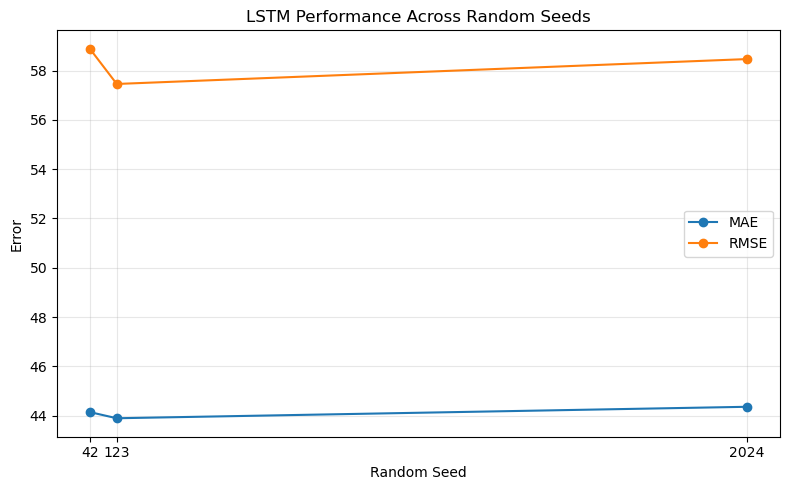

Saved: TASK8_three_seed_results.png


In [8]:
# ============================================================
# TASK 8 — SAVE THREE-SEED RESULTS FIGURE
# ============================================================

import matplotlib.pyplot as plt

seed_plot_df = pd.DataFrame({
    "Seed": [42, 123, 2024],
    "MAE": [44.143620, 43.894558, 44.359749],
    "RMSE": [58.884875, 57.458213, 58.468445],
    "R2": [0.214766, 0.252354, 0.225833]
})

plt.figure(figsize=(8, 5))

plt.plot(seed_plot_df["Seed"], seed_plot_df["MAE"],
         marker="o", label="MAE")
plt.plot(seed_plot_df["Seed"], seed_plot_df["RMSE"],
         marker="o", label="RMSE")

plt.xlabel("Random Seed")
plt.ylabel("Error")
plt.title("LSTM Performance Across Random Seeds")
plt.xticks([42, 123, 2024])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "TASK8_three_seed_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: TASK8_three_seed_results.png")